<a href="https://colab.research.google.com/github/Yash-k10/pattern_recognition/blob/main/Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

MODEL WITHOUT PCA/LDA
Accuracy: 0.7532467532467533

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy              

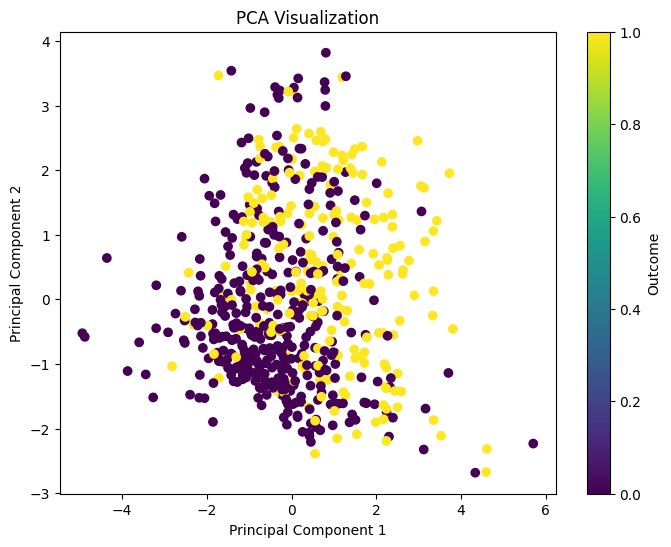

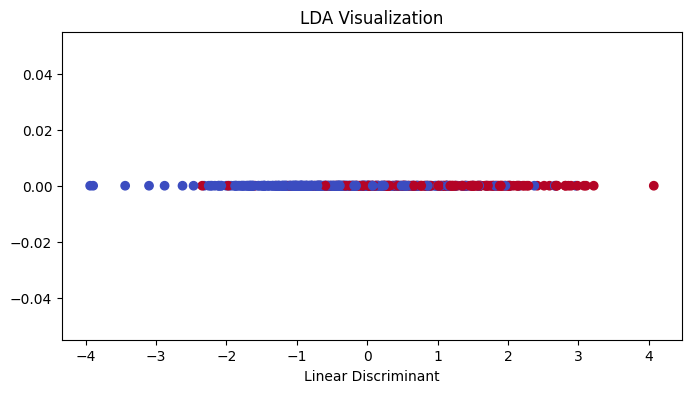

In [1]:
# ======================================================
# PRACTICAL: Feature Extraction using PCA and LDA
# Disease Prediction using Diabetes Dataset
# ======================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------------------

df = pd.read_csv('/content/diabetes.csv')

print("First 5 rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# ------------------------------------------------------
# Step 3: Separate Features and Target
# ------------------------------------------------------

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# ------------------------------------------------------
# Step 4: Train-Test Split
# ------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------
# Step 5: Standardization
# ------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================================================
# BASE MODEL (Without PCA/LDA)
# ======================================================

print("\n==============================")
print("MODEL WITHOUT PCA/LDA")
print("==============================")

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))

# ======================================================
# PCA
# ======================================================

print("\n==============================")
print("PCA")
print("==============================")

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original Features :", X_train.shape[1])
print("Reduced Features :", X_train_pca.shape[1])

print("\nExplained Variance Ratio")
print(pca.explained_variance_ratio_)

# Train Model

model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

pred_pca = model_pca.predict(X_test_pca)

print("\nAccuracy after PCA:", accuracy_score(y_test, pred_pca))

# ======================================================
# LDA
# ======================================================

print("\n==============================")
print("LDA")
print("==============================")

lda = LDA(n_components=1)

X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print("Original Features :", X_train.shape[1])
print("Reduced Features :", X_train_lda.shape[1])

model_lda = LogisticRegression(max_iter=1000)

model_lda.fit(X_train_lda, y_train)

pred_lda = model_lda.predict(X_test_lda)

print("\nAccuracy after LDA:", accuracy_score(y_test, pred_lda))

# ======================================================
# Confusion Matrix
# ======================================================

print("\nConfusion Matrix (LDA)")
print(confusion_matrix(y_test, pred_lda))

# ======================================================
# PCA Visualization
# ======================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.colorbar(label='Outcome')
plt.show()

# ======================================================
# LDA Visualization
# ======================================================

plt.figure(figsize=(8,4))

plt.scatter(
    X_train_lda,
    np.zeros_like(X_train_lda),
    c=y_train,
    cmap='coolwarm'
)

plt.xlabel("Linear Discriminant")
plt.title("LDA Visualization")

plt.show()